In [1]:
!pip install -q \
    numpy==1.26.4 \
    transformers==4.41.2 \
    datasets==2.20.0 \
    accelerate==0.33.0 \
    jiwer==3.0.4




In [2]:
from datasets import load_dataset

ds = load_dataset("Teklia/IAM-line")  # train/validation/test
print(ds)
print(ds["train"][0].keys())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/6482 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/976 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2915 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 6482
    })
    validation: Dataset({
        features: ['image', 'text'],
        num_rows: 976
    })
    test: Dataset({
        features: ['image', 'text'],
        num_rows: 2915
    })
})
dict_keys(['image', 'text'])


In [3]:
# Some datasets use different label field names; detect it safely
sample = ds["train"][0]
print("Keys:", sample.keys())

# try common candidates
for cand in ["text", "label", "transcription", "sentence", "gt"]:
    if cand in sample:
        label_col = cand
        break
else:
    raise ValueError("Couldn't find text label column. Print sample keys and choose one manually.")

print("Using label column:", label_col)


Keys: dict_keys(['image', 'text'])
Using label column: text


In [4]:
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten").to(device)

# patch token ids (required)
model.config.decoder_start_token_id = processor.tokenizer.bos_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.eos_token_id

print("patched:", model.config.decoder_start_token_id, model.config.pad_token_id, model.config.eos_token_id)



Device: cuda


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

patched: 0 1 2


In [6]:
# ---- PATCH token ids (fixes decoder_start_token_id error) ----
bos = processor.tokenizer.bos_token_id
pad = processor.tokenizer.pad_token_id
eos = processor.tokenizer.eos_token_id

setattr(model.config, "decoder_start_token_id", bos)
setattr(model.config, "pad_token_id", pad)
setattr(model.config, "eos_token_id", eos)

setattr(model.generation_config, "decoder_start_token_id", bos)
setattr(model.generation_config, "pad_token_id", pad)
setattr(model.generation_config, "eos_token_id", eos)

print("✅ decoder_start_token_id:", model.config.decoder_start_token_id)
print("✅ pad_token_id:", model.config.pad_token_id)
print("✅ eos_token_id:", model.config.eos_token_id)



✅ decoder_start_token_id: 0
✅ pad_token_id: 1
✅ eos_token_id: 2


In [7]:
from datasets import DatasetDict

train_small = ds["train"].shuffle(seed=42).select(range(1000))
val_small   = ds["validation"].shuffle(seed=42).select(range(200))
test_small  = ds["test"].shuffle(seed=42).select(range(200))

small = DatasetDict(train=train_small, validation=val_small, test=test_small)
print(small)


DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 1000
    })
    validation: Dataset({
        features: ['image', 'text'],
        num_rows: 200
    })
    test: Dataset({
        features: ['image', 'text'],
        num_rows: 200
    })
})


In [10]:
from torch.utils.data import DataLoader
def collate_fn(examples):
    images = []
    texts = []
    for ex in examples:
        img = ex["image"]
        # Ensure PIL + RGB (fixes ndim=2 grayscale)
        if hasattr(img, "convert"):
            img = img.convert("RGB")
        images.append(img)
        texts.append(ex[label_col])

    pixel_values = processor(images=images, return_tensors="pt").pixel_values
    labels = processor.tokenizer(texts, return_tensors="pt", padding=True, truncation=True).input_ids
    labels[labels == processor.tokenizer.pad_token_id] = -100

    return {"pixel_values": pixel_values, "labels": labels, "texts": texts}

train_loader = DataLoader(small["train"], batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(small["validation"], batch_size=4, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(small["test"], batch_size=4, shuffle=False, collate_fn=collate_fn)



In [11]:
from tqdm import tqdm

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

model.train()
for epoch in range(3):
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        out = model(pixel_values=pixel_values, labels=labels)
        loss = out.loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        pbar.set_postfix(loss=float(loss.detach().cpu()))



Epoch 3: 100%|██████████| 250/250 [03:49<00:00,  1.09it/s, loss=0.0104]


In [12]:
import jiwer

model.eval()
preds, refs = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        pixel_values = batch["pixel_values"].to(device)
        gt_texts = batch["texts"]

        generated_ids = model.generate(pixel_values, max_length=64)
        pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)

        preds.extend(pred_texts)
        refs.extend(gt_texts)
print("len(refs):", len(refs), "len(preds):", len(preds))
print("type(refs[0]):", type(refs[0]), "type(preds[0]):", type(preds[0]))
print("Empty preds:", sum(1 for x in preds if len(x.strip()) == 0), "/", len(preds))

for i in range(5):
    print("\n--- SAMPLE", i, "---")
    print("GT  :", refs[i])
    print("PRED:", preds[i])

cer = jiwer.cer(refs, preds)
wer = jiwer.wer(refs, preds)

print("CER:", cer)
print("WER:", wer)


Evaluating: 100%|██████████| 50/50 [00:55<00:00,  1.10s/it]

len(refs): 200 len(preds): 200
type(refs[0]): <class 'str'> type(preds[0]): <class 'str'>
Empty preds: 0 / 200

--- SAMPLE 0 ---
GT  : the washing-up - while others , if they
PRED: the washing-up - while others, if they

--- SAMPLE 1 ---
GT  : which causes them to wake feeling worse
PRED: which causes them to make feeding worse

--- SAMPLE 2 ---
GT  : faith which he was placing in her and
PRED: fate which he was'placing in her and

--- SAMPLE 3 ---
GT  : Epicures and gourmands , sated by the
PRED: Epicures and governments, sated by the

--- SAMPLE 4 ---
GT  : he had flown to England , attended the vital
PRED: he had flown to England, attended the vital
CER: 0.08589786946229286
WER: 0.33206521739130435


In [15]:
import time, numpy as np
import torch
from tqdm import tqdm

assert device == "cuda", "Set runtime to GPU (T4) for this benchmark."

model.eval()
torch.set_grad_enabled(False)

def sync():
    torch.cuda.synchronize()

def percentile(x, p):
    return float(np.percentile(np.array(x), p))

In [16]:
# Collect ~N images from the test set
N = 50
images = [small["test"][i]["image"].convert("RGB") for i in range(N)]

# Preprocess once (so we measure model/generate, not preprocessing)
pixel_values_list = []
for img in images:
    pv = processor(images=img, return_tensors="pt").pixel_values
    pixel_values_list.append(pv)

# Warmup (important on GPU)
for _ in range(10):
    pv = pixel_values_list[0].to(device)
    _ = model.generate(pv, max_length=64)
sync()

# Timed runs
lat_ms = []
for pv in tqdm(pixel_values_list, desc="Benchmarking single-image latency"):
    pv = pv.to(device)
    sync()
    t0 = time.perf_counter()
    _ = model.generate(pv, max_length=64)
    sync()
    t1 = time.perf_counter()
    lat_ms.append((t1 - t0) * 1000)

print(f"\nSingle-image latency over N={N}:")
print("Mean (ms):", float(np.mean(lat_ms)))
print("P50  (ms):", percentile(lat_ms, 50))
print("P95  (ms):", percentile(lat_ms, 95))
print("Min  (ms):", float(np.min(lat_ms)))
print("Max  (ms):", float(np.max(lat_ms)))

Benchmarking single-image latency: 100%|██████████| 50/50 [00:13<00:00,  3.76it/s]


Single-image latency over N=50:
Mean (ms): 264.2911493200245
P50  (ms): 248.1875924997894
P95  (ms): 360.85986820025937
Min  (ms): 169.01464199963812
Max  (ms): 482.23565700027393


In [17]:
def benchmark_throughput(batch_size=4, steps=50):
    # Take `steps` batches from the test set
    loader = torch.utils.data.DataLoader(
        small["test"],
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn
    )

    # Warmup (3 batches)
    it = iter(loader)
    for _ in range(3):
        batch = next(it)
        pv = batch["pixel_values"].to(device)
        _ = model.generate(pv, max_length=64)
    sync()

    # Timed
    total_images = 0
    t0 = time.perf_counter()
    it = iter(loader)
    for _ in range(steps):
        batch = next(it)
        pv = batch["pixel_values"].to(device)
        _ = model.generate(pv, max_length=64)
        total_images += pv.shape[0]
    sync()
    t1 = time.perf_counter()

    sec = (t1 - t0)
    ips = total_images / sec
    return ips, sec, total_images

for bs in [1, 2, 4, 8]:
    ips, sec, total = benchmark_throughput(batch_size=bs, steps=25)
    print(f"Batch size {bs:>2}: {ips:.2f} images/sec (total {total} images, {sec:.2f}s)")

Batch size  1: 2.36 images/sec (total 25 images, 10.60s)
Batch size  2: 4.14 images/sec (total 50 images, 12.08s)
Batch size  4: 3.73 images/sec (total 100 images, 26.78s)
Batch size  8: 3.47 images/sec (total 200 images, 57.71s)


In [18]:
# Measure preprocessing time (PIL -> pixel_values)
prep_ms = []
for img in tqdm(images, desc="Benchmarking preprocessing"):
    t0 = time.perf_counter()
    _ = processor(images=img, return_tensors="pt").pixel_values
    t1 = time.perf_counter()
    prep_ms.append((t1 - t0) * 1000)

print("\nPreprocessing latency per image:")
print("Mean (ms):", float(np.mean(prep_ms)))
print("P50  (ms):", percentile(prep_ms, 50))
print("P95  (ms):", percentile(prep_ms, 95))

Benchmarking preprocessing: 100%|██████████| 50/50 [00:00<00:00, 167.40it/s]


Preprocessing latency per image:
Mean (ms): 5.942694040004426
P50  (ms): 5.803453999988051
P95  (ms): 6.819057199913914


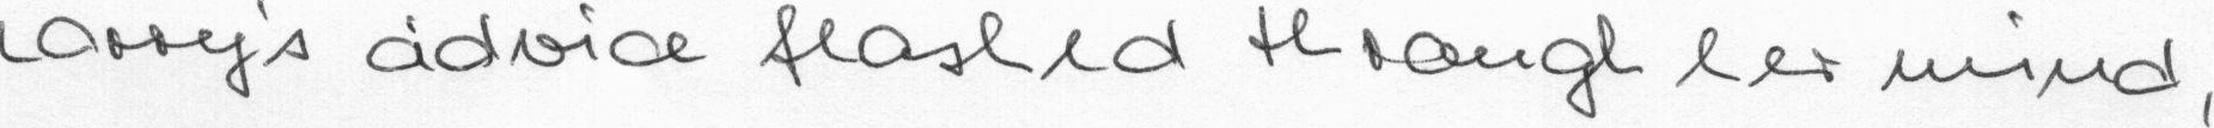

Ground Truth: Larry's advice flashed through her mind ,
Prediction : Lory's advice flashed through her mind,


In [19]:
from IPython.display import display
import torch

model.eval()

# Pick any test image (change index if you want)
idx = 5
sample = small["test"][idx]

# Ensure RGB
image = sample["image"].convert("RGB")
gt_text = sample[label_col]

display(image)
print("Ground Truth:", gt_text)

# Preprocess
pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)

# Inference (stable greedy decoding)
with torch.no_grad():
    ids = model.generate(
        pixel_values,
        max_length=64,
        do_sample=False
    )

pred_text = processor.batch_decode(ids, skip_special_tokens=True)[0]

print("Prediction :", pred_text)